In [202]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import xarray as xr
import numpy as np
import pandas as pd
import pygmt

In [203]:
crust_thick = [3592, 7402, 6284]

In [204]:
layers = {
    'water': {'thickness': 2000, 'density': 1030, 'color': 'blue'},
    'sediment': {'thickness': 600,  'density': 1880, 'color': 'tan'},
    'crust': {'thickness': crust_thick, 'density': 2750, 'color': 'sienna'},
    'mantle': {'thickness': 3000,'density': 3200, 'color': 'red'}}

In [205]:
layers['crust']['thickness'][1]

7402

In [206]:
rho1 = 500
r1 = 400
z1 = 3250

v1 = 4 / 3 * np.pi * r1**3

L = 100
dL = 2
s1 = 50

G = 6.674 * 1e-11  # grav constant
dx = np.arange(0, L, dL)  # matrix of survey
x1 = dx - s1

n1 = (x1**2 + z1**2)**1.5
g1 = G * rho1 * v1 * z1 / n1 * 1e5

In [207]:
# fig, (ax0, ax1) = plt.subplots(2,1, figsize=(8, 10), sharex=True)

# ax0.plot(dx, g1, color='black', label='Gravitational Anomaly', linewidth=1)
# ax0.scatter(dx[np.argmax(g1)], g1[np.argmax(g1)], color='red', edgecolors='red', marker='*', s=50, label='Max Anomaly')
# ax0.text(dx[np.argmax(g1)], g1[np.argmax(g1)], f'{g1[np.argmax(g1)]:.3f} mGal', fontsize=8, va='bottom', ha='center')

# ax0.set_ylim(np.min(g1), np.max(g1) + 0.0005)
# ax0.set_ylabel('mGal')

# width = 2  # width for each column

# for i, row in profile.iterrows():
#     long = row['long']
#     crust_thick = row['ps_z']   # this is what varies per longitude

#     x0 = long - width / 2
#     x1 = long + width / 2


#     layers = {
#     'water': {'thickness': 2000, 'density': 1030, 'color': 'blue'},
#     'sediment': {'thickness': 445,  'density': 1880, 'color': 'tan'},
#     'crust': {'thickness': crust_thick, 'density': 2750, 'color': 'sienna'},
#     'mantle': {'thickness': 3000,'density': 3200, 'color': 'red'}}

#     bottom = 0
#     polys = {}

    
#     # name is key, l is value
#     for name, l in layers.items():
#         # print(f'name: {name}\n l: {l}')
#         n = l['thickness']
#         rho_l = l['density']
#         top = bottom + n

#         #bl, br, tl, tr
#         verts = [(x0, bottom), (x1, bottom),
#             (x1, top), (x0, top)]

#         poly = Polygon(verts, closed=True, facecolor=l['color'], edgecolor='black', linewidth=0.5)
#         ax1.add_patch(poly)

#         ax1.text(x0 + (x1 - x0) + 10, bottom + n/2, f't: {n} m\nρ: {rho_l} kg/m³', 
#                 va='center', ha='left', fontsize=8)

#         # stores the polygon under its layer name in the dict 
#         polys[name] = poly

#         bottom += n

# # loc of sphere vs depth
# # ax1.scatter(s1, z1, color='indigo', marker='o', s=r1, label='Buried Sphere 1', edgecolors='black')
# # ax1.text(s1, z1 + r1 + 400, f'r: {r1} m\nρ: {rho1} kg/m³', fontsize=8, va='top', ha='center')


# ax1.set_xlim(profile['long'].min(), profile['long'].max())
# ax1.set_ylim(0, bottom)
# ax1.set_ylabel('Thickness (m)')
# ax1.set_xlabel('Distance (m)')
# ax1.invert_yaxis()

# # leg = ax1.legend(loc='lower left', fontsize=10)
# # for handle in leg.legend_handles:
# #     handle.set_sizes([50])

# fig.suptitle(f'4 Layer Model with Gravity Anomaly at Latitude {lat}', fontsize=12)
# fig.subplots_adjust(top=0.94, hspace=0.1)

# plt.savefig(f'..\\..\\figures\\4lay\\lat{lat}ps_z_4laymod.png', dpi=400, bbox_inches='tight')
# plt.show()


name: water
layer: {'thickness': 2000, 'density': 1030, 'color': 'blue'}
bl, br, tl, tr verts for 2000: [(0, 0), (100, 0), (100, 2000), (0, 2000)]

name: sediment
layer: {'thickness': 600, 'density': 1880, 'color': 'tan'}
bl, br, tl, tr verts for 600: [(0, 2000), (100, 2000), (100, 2600), (0, 2600)]

name: crust
layer: {'thickness': [3592, 7402, 6284], 'density': 2750, 'color': 'sienna'}
max_thick: 7402
thickness: 3592
bl, br, tl, tr verts for 3592: [(0, 2600), (33.333333333333336, 2600), (33.333333333333336, 6192), (0, 6192)]
thickness: 7402
bl, br, tl, tr verts for 7402: [(33.333333333333336, 2600), (66.66666666666667, 2600), (66.66666666666667, 10002), (33.333333333333336, 10002)]
thickness: 6284
bl, br, tl, tr verts for 6284: [(66.66666666666667, 2600), (100.0, 2600), (100.0, 8884), (66.66666666666667, 8884)]

name: mantle
layer: {'thickness': 3000, 'density': 3200, 'color': 'red'}
bl, br, tl, tr verts for 3000: [(0, 10002), (100, 10002), (100, 13002), (0, 13002)]


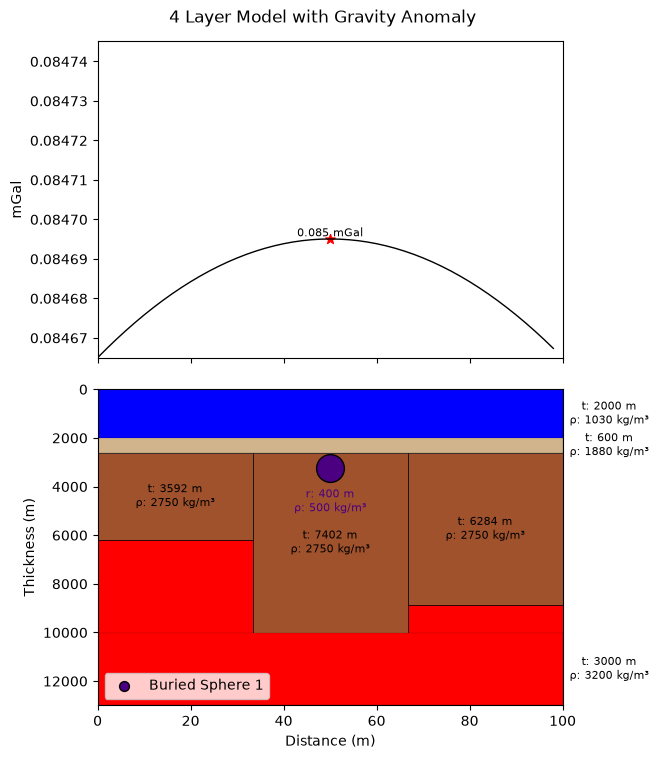

In [208]:
fig, (ax0, ax1) = plt.subplots(2,1, figsize=(6, 8), sharex=True)

ax0.plot(dx, g1, color='black', label='Gravitational Anomaly', linewidth=1)
ax0.scatter(dx[np.argmax(g1)], g1[np.argmax(g1)], color='red', edgecolors='red', marker='*', s=50, label='Max Anomaly')
ax0.text(dx[np.argmax(g1)], g1[np.argmax(g1)], f'{g1[np.argmax(g1)]:.3f} mGal', fontsize=8, va='bottom', ha='center')

ax0.set_ylim(np.min(g1), np.max(g1) + 0.00005)
ax0.set_ylabel('mGal')

# defining poly geom
x0 = 0
x1 = L
bottom = 0

polys = {}


mantle_color = layers['mantle']['color']
mantle_density = layers['mantle']['density']

# name is key, l is value
for name, l in layers.items():
    print(f'\nname: {name}')
    print(f'layer: {l}')
    

    if name=='crust':
        wl = x0
        col_width = L/3
        max_thick = max(l['thickness'])
        print(f'max_thick: {max_thick}')

        for k in enumerate(l['thickness']):
            n = k[1]
            print(f'thickness: {n}')

            rho_l = l['density']
            top = bottom + n
            wr = wl + col_width

            #bl, br, tl, tr
            verts = [(wl, bottom), (wr, bottom),
                (wr, top), (wl, top)]

            print(f'bl, br, tl, tr verts for {n}: {verts}')

            poly = Polygon(verts, closed=True, facecolor=l['color'], edgecolor='black', linewidth=0.5)
            ax1.add_patch(poly)

            ax1.text((wl + wr) / 2, bottom + n/2, f't: {n} m\nρ: {rho_l} kg/m³', 
                    va='center', ha='center', fontsize=8, color='black')

            # stores the polygon under its layer name in the dict 
            polys[name] = poly

            # adding mantle beneath thinner pieces
            gap = max_thick - n
            if gap > 0:
                fill_verts = [(wl, top), (wr, top),
                                (wr, top + gap), (wl, top + gap)]

                fill_poly = Polygon(fill_verts, closed=True, facecolor=mantle_color,
                                        edgecolor='black', linewidth=0.5)
                ax1.add_patch(fill_poly)

            wl = wr

        bottom += max_thick
        

    else:
        n = l['thickness']

        rho_l = l['density']
        top = bottom + n

        #bl, br, tl, tr
        verts = [(x0, bottom), (x1, bottom),
            (x1, top), (x0, top)]

        print(f'bl, br, tl, tr verts for {n}: {verts}')

        poly = Polygon(verts, closed=True, facecolor=l['color'], edgecolor='black', linewidth=0.1)
        ax1.add_patch(poly)

        ax1.text(x1 + 10, bottom + n/2, f't: {n} m\nρ: {rho_l} kg/m³', 
                va='center', ha='center', fontsize=8)

        # stores the polygon under its layer name in the dict 
        polys[name] = poly

        bottom += n

# loc of sphere vs depth
ax1.scatter(s1, z1, color='indigo', marker='o', s=r1, label='Buried Sphere 1', edgecolors='black')
ax1.text(s1, z1 + r1 + 400, f'r: {r1} m\nρ: {rho1} kg/m³', fontsize=8, va='top', ha='center', color='indigo')

ax1.set_xlim(0, x1)
ax1.set_ylim(0, bottom)
ax1.set_ylabel('Thickness (m)')
ax1.set_xlabel('Distance (m)')
ax1.invert_yaxis()

leg = ax1.legend(loc='lower left', fontsize=10)
for handle in leg.legend_handles:
    handle.set_sizes([50])

fig.suptitle('4 Layer Model with Gravity Anomaly', fontsize=12)
fig.subplots_adjust(top=0.94, hspace=0.1)

plt.savefig('..\\..\\figures\\4lay\\test_4laymod.png', dpi=400, bbox_inches='tight')
plt.show()